# Task 5: Personal Loan Acceptance Prediction

## 1. Introduction & Problem Statement

Banks often run telemarketing campaigns to promote financial products such as term deposits and personal loan offers. Not every customer responds positively, and contacting uninterested customers wastes resources and time.

**Objective:** Predict which customers are likely to **accept a personal loan offer** (subscribe to a term deposit) using demographic and campaign-related data.

**Business Goal:** By identifying high-potential customer segments, the bank can:
- Focus marketing efforts on likely subscribers
- Reduce campaign costs
- Improve customer experience by avoiding unnecessary calls

**Dataset:** UCI Bank Marketing Dataset (`bank.csv`) containing **11,162 customer records** with 16 features and 1 target variable (`deposit`: yes/no).

**Approach:**
1. Explore and understand the data
2. Clean and preprocess it
3. Perform EDA to uncover patterns
4. Train Logistic Regression and Decision Tree classifiers
5. Evaluate and compare model performance
6. Extract business insights

---
## 2. Import Libraries

In [1]:
# ── Standard libraries ──────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

# ── Scikit-learn: Preprocessing ──────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# ── Scikit-learn: Models ─────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ── Scikit-learn: Evaluation ─────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

print("All libraries imported successfully!")

All libraries imported successfully!


---
## 3. Dataset Understanding & Description

In [2]:
# ── Load the dataset ─────────────────────────────────────────────────────
df = pd.read_csv('bank.csv')

print(f"Dataset Shape  : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Memory Usage   : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print("\n── First 5 rows ──")
df.head()

Dataset Shape  : 11162 rows × 17 columns
Memory Usage   : 6511.1 KB

── First 5 rows ──


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
# ── Column data types ─────────────────────────────────────────────────────
print("Feature Information:")
print("=" * 45)
df.info()

Feature Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [4]:
# ── Statistical summary for numerical columns ─────────────────────────────
print("Statistical Summary (Numerical Features):")
df.describe().round(2)

Statistical Summary (Numerical Features):


,age,balance,day,duration,campaign,pdays,previous
count,11162.00,11162.00,11162.00,11162.00,11162.00,11162.00,11162.00
mean,41.23,1528.54,15.66,371.99,2.51,51.33,0.83
std,11.91,3225.41,8.42,347.13,2.72,108.76,2.29
min,18.00,-6847.00,1.00,2.00,1.00,-1.00,0.00
25%,32.00,122.00,8.00,138.00,1.00,-1.00,0.00
50%,39.00,550.00,15.00,255.00,2.00,-1.00,0.00
75%,49.00,1708.00,22.00,496.00,3.00,20.75,1.00
max,95.00,81204.00,31.00,3881.00,63.00,854.00,58.00


In [5]:
# ── Dataset column descriptions ───────────────────────────────────────────
col_desc = {
    'age'      : 'Customer age (numeric)',
    'job'      : 'Type of job (categorical)',
    'marital'  : 'Marital status (married/single/divorced)',
    'education': 'Education level (primary/secondary/tertiary)',
    'default'  : 'Has credit in default? (yes/no)',
    'balance'  : 'Average yearly balance in euros (numeric)',
    'housing'  : 'Has housing loan? (yes/no)',
    'loan'     : 'Has personal loan? (yes/no)',
    'contact'  : 'Contact communication type (telephone/cellular/unknown)',
    'day'      : 'Last contact day of the month (numeric)',
    'month'    : 'Last contact month of the year',
    'duration' : 'Last contact duration in seconds (numeric)',
    'campaign' : 'Number of contacts during this campaign',
    'pdays'    : 'Days since last contacted from a previous campaign (-1 = never)',
    'previous' : 'Number of contacts before this campaign',
    'poutcome' : 'Outcome of previous marketing campaign',
    'deposit'  : 'TARGET: Has the client subscribed a term deposit? (yes/no)'
}
desc_df = pd.DataFrame(list(col_desc.items()), columns=['Column', 'Description'])
print("Column Descriptions:")
desc_df

Column Descriptions:


,Column,Description
0,age,Customer age (numeric)
1,job,Type of job (categorical)
2,marital,Marital status (married/single/divorced)
3,education,Education level (primary/secondary/tertiary)
4,default,Has credit in default? (yes/no)
5,balance,Average yearly balance in euros (numeric)
6,housing,Has housing loan? (yes/no)
7,loan,Has personal loan? (yes/no)
8,contact,Contact communication type (telephone/cellular...
9,day,Last contact day of the month (numeric)


---
## 4. Data Cleaning & Preparation

In [6]:
# ── Step 4.1: Check for missing values ───────────────────────────────────
missing = df.isnull().sum()
print("Missing Values per Column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")

Missing Values per Column:
No missing values found!


In [7]:
# ── Step 4.2: Check for duplicate rows ───────────────────────────────────
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes}")

# Remove duplicates if any
if dupes > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates detected.")

Duplicate rows found: 0
No duplicates detected.


In [8]:
# ── Step 4.3: Identify and handle 'unknown' category values ──────────────
cat_cols = df.select_dtypes(include='object').columns.tolist()

print("Categorical columns with 'unknown' values:")
for col in cat_cols:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        pct = count / len(df) * 100
        print(f"  {col:15s}: {count:5d} unknowns ({pct:.1f}%)")

# Replace 'unknown' in poutcome with 'not_contacted' for clarity
df['poutcome'] = df['poutcome'].replace('unknown', 'not_contacted')

print("\n'unknown' in poutcome relabelled to 'not_contacted'.")

Categorical columns with 'unknown' values:
  job            :    70 unknowns (0.6%)
  education      :   497 unknowns (4.5%)
  contact        :  2346 unknowns (21.0%)
  poutcome       :  8326 unknowns (74.6%)

'unknown' in poutcome relabelled to 'not_contacted'.


In [9]:
# ── Step 4.4: Feature Engineering ────────────────────────────────────────
# Create age group bins for easier analysis and segmentation
bins  = [17, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# Create a flag for customers previously contacted in a past campaign
df['prev_contacted'] = (df['pdays'] != -1).astype(int)

print("New features created:")
print("   → age_group     : Categorises age into 6 bands")
print("   → prev_contacted: 1 if customer was contacted before, 0 otherwise")
df[['age', 'age_group', 'pdays', 'prev_contacted']].head()

New features created:
   → age_group     : Categorises age into 6 bands
   → prev_contacted: 1 if customer was contacted before, 0 otherwise


,age,age_group,pdays,prev_contacted
0,59,56-65,-1,0
1,56,56-65,-1,0
2,41,36-45,-1,0
3,55,46-55,-1,0
4,54,46-55,-1,0


In [10]:
# ── Step 4.5: Encode target variable ─────────────────────────────────────
# Convert 'deposit' from yes/no to 1/0 for model training
df['deposit_binary'] = (df['deposit'] == 'yes').astype(int)

print("Target class distribution after encoding:")
print(df['deposit_binary'].value_counts())
print(f"\nClass balance: {df['deposit_binary'].mean()*100:.1f}% positive (accepted deposit)")

Target class distribution after encoding:
deposit_binary
0    5873
1    5289
Name: count, dtype: int64

Class balance: 47.4% positive (accepted deposit)


---
## 5. Exploratory Data Analysis (EDA)

### 5.1 Target Variable Distribution

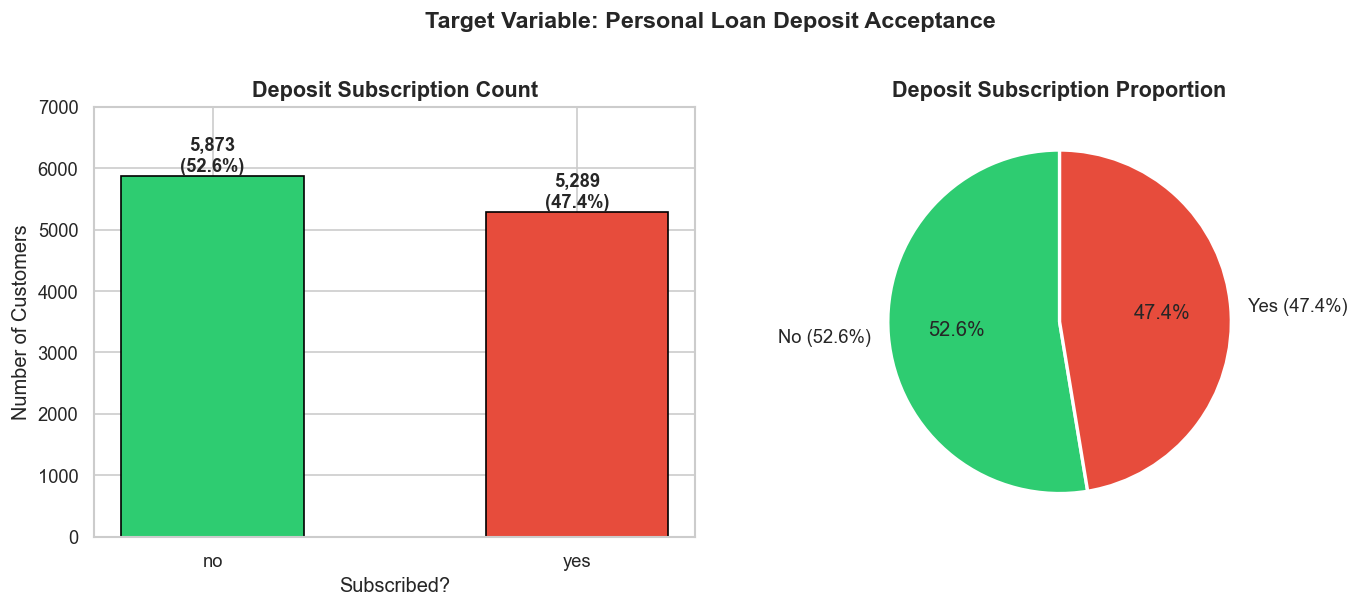

→ The dataset is nearly balanced: 47.4% accepted vs 52.6% declined.


In [11]:
# ── Target class distribution (pie + bar) ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['deposit'].value_counts()
colors = ['#2ecc71', '#e74c3c']

# Bar chart
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 80, f'{v:,}\n({v/len(df)*100:.1f}%)', 
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Deposit Subscription Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Subscribed?')
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, 7000)

# Pie chart
axes[1].pie(counts.values, labels=['No (52.6%)', 'Yes (47.4%)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Deposit Subscription Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Personal Loan Deposit Acceptance', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_target_dist.png', bbox_inches='tight')
plt.show()
print("→ The dataset is nearly balanced: 47.4% accepted vs 52.6% declined.")

### 5.2 Age Distribution by Deposit Outcome

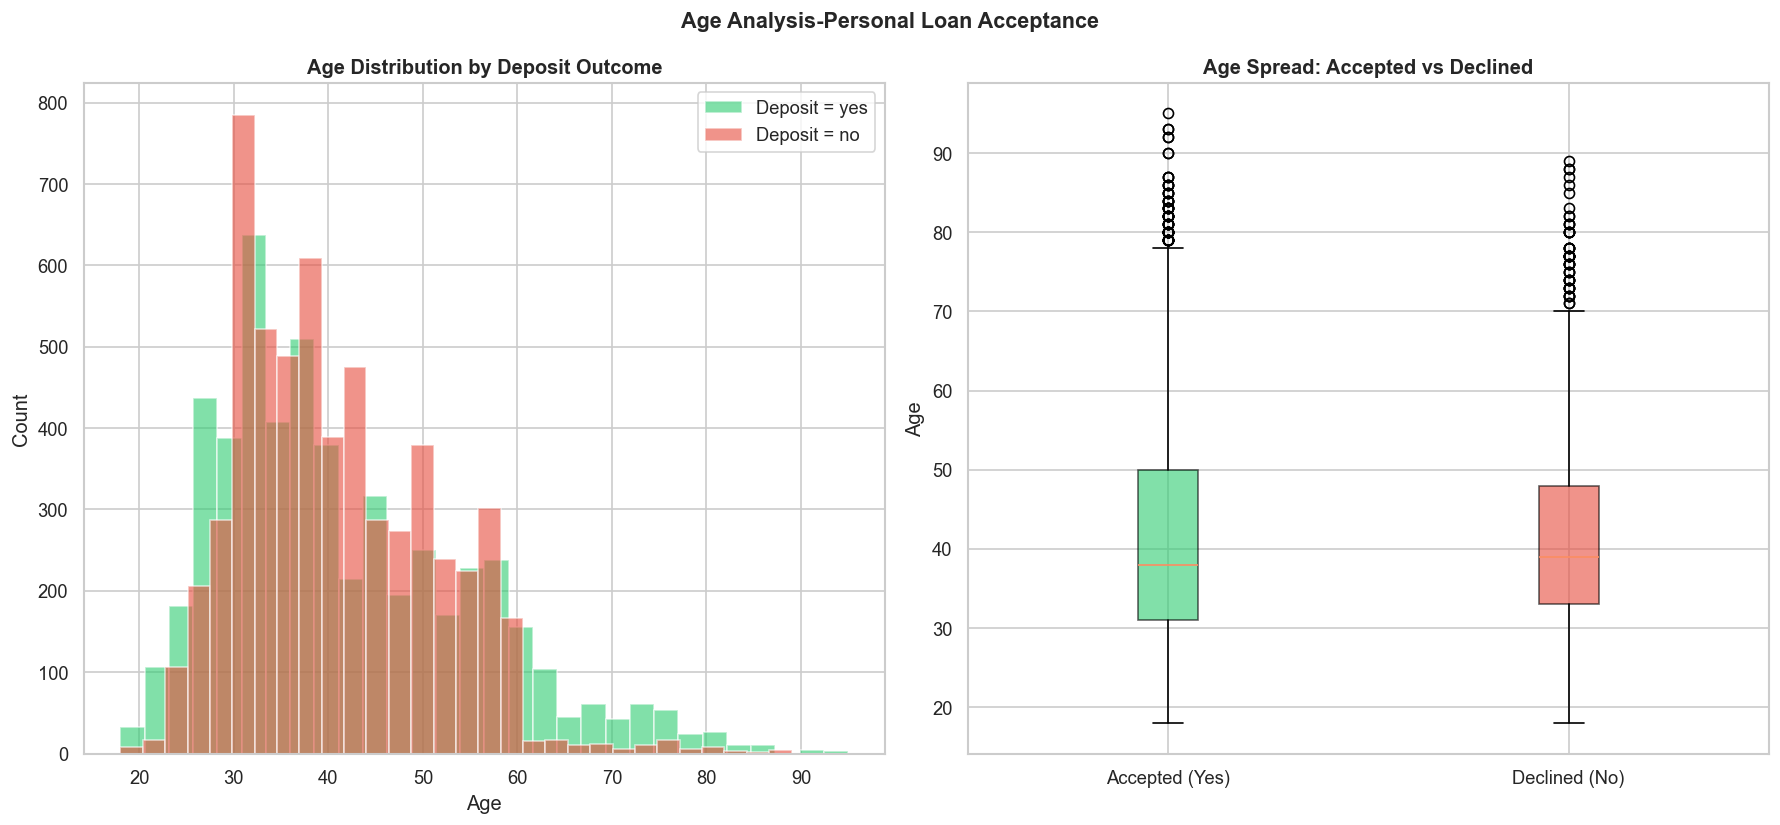

Avg age (Accepted) : 41.7  |  Avg age (Declined): 40.8


In [15]:
# ── Age distribution: deposit yes vs no ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Histogram: Age distribution by outcome
for label, color in [('yes', '#2ecc71'), ('no', '#e74c3c')]:
    axes[0].hist(df[df['deposit'] == label]['age'], bins=30, alpha=0.6,
                 color=color, label=f'Deposit = {label}', edgecolor='white')
axes[0].set_title('Age Distribution by Deposit Outcome', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot: Age by deposit
deposit_yes = df[df['deposit'] == 'yes']['age']
deposit_no  = df[df['deposit'] == 'no']['age']
bp = axes[1].boxplot([deposit_yes, deposit_no], patch_artist=True,
                     labels=['Accepted (Yes)', 'Declined (No)'],
                     boxprops=dict(facecolor='#2ecc71', alpha=0.6))
bp['boxes'][1].set_facecolor('#e74c3c')
axes[1].set_title('Age Spread: Accepted vs Declined', fontweight='bold')
axes[1].set_ylabel('Age')

plt.suptitle('Age Analysis-Personal Loan Acceptance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_age_dist.png', bbox_inches='tight')
plt.show()
print(f"Avg age (Accepted) : {deposit_yes.mean():.1f}  |  Avg age (Declined): {deposit_no.mean():.1f}")

### 5.3 Job Type vs. Deposit Acceptance

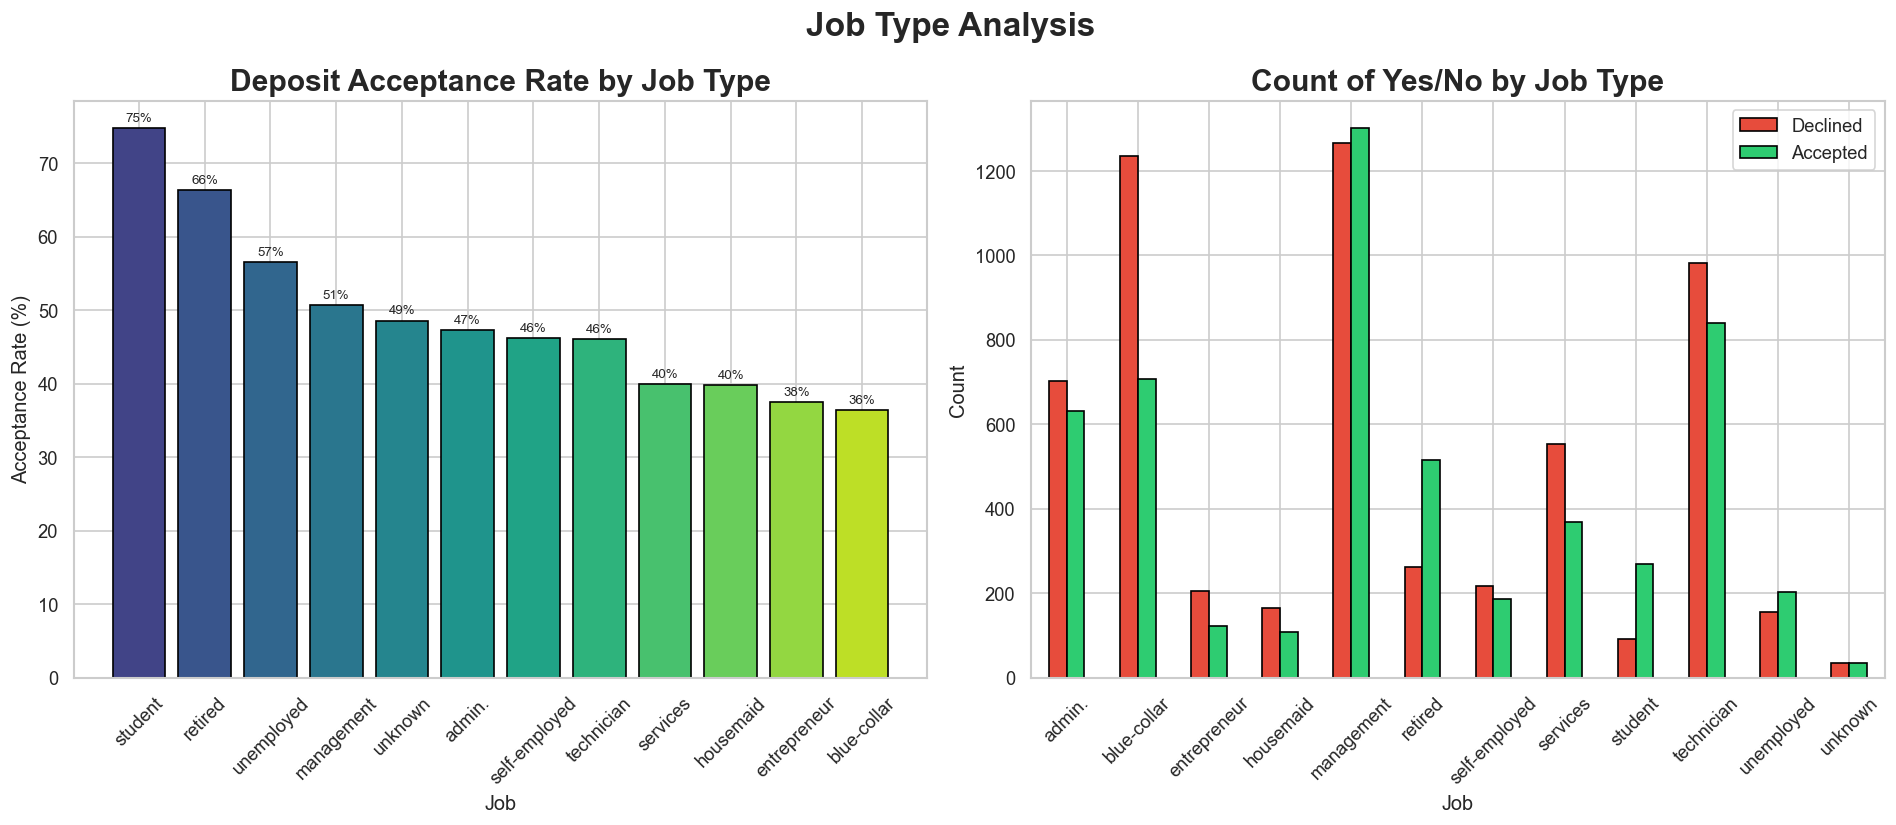

Top 3 job types most likely to accept:
job
student       74.7%
retired       66.3%
unemployed    56.6%
Name: deposit_binary, dtype: object


In [20]:
# ── Acceptance rate by job type ───────────────────────────────────────────
job_rate = df.groupby('job')['deposit_binary'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Acceptance rate per job
bars = axes[0].bar(job_rate.index, job_rate.values * 100,
                   color=plt.cm.viridis(np.linspace(0.2, 0.9, len(job_rate))),
                   edgecolor='black')
axes[0].set_title('Deposit Acceptance Rate by Job Type', fontsize=18, fontweight='bold')
axes[0].set_xlabel('Job')
axes[0].set_ylabel('Acceptance Rate (%)')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, job_rate.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val*100:.0f}%', ha='center', va='bottom', fontsize=8)

# Stacked bar: count by job and deposit
job_deposit = df.groupby(['job', 'deposit']).size().unstack()
job_deposit.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'],
                 edgecolor='black', stacked=False)
axes[1].set_title('Count of Yes/No by Job Type', fontsize=18, fontweight='bold')
axes[1].set_xlabel('Job')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(['Declined', 'Accepted'])

plt.suptitle('Job Type Analysis', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_job.png', bbox_inches='tight')
plt.show()
print("Top 3 job types most likely to accept:")
print(job_rate.head(3).apply(lambda x: f'{x*100:.1f}%'))

### 5.4 Marital Status & Education vs. Deposit

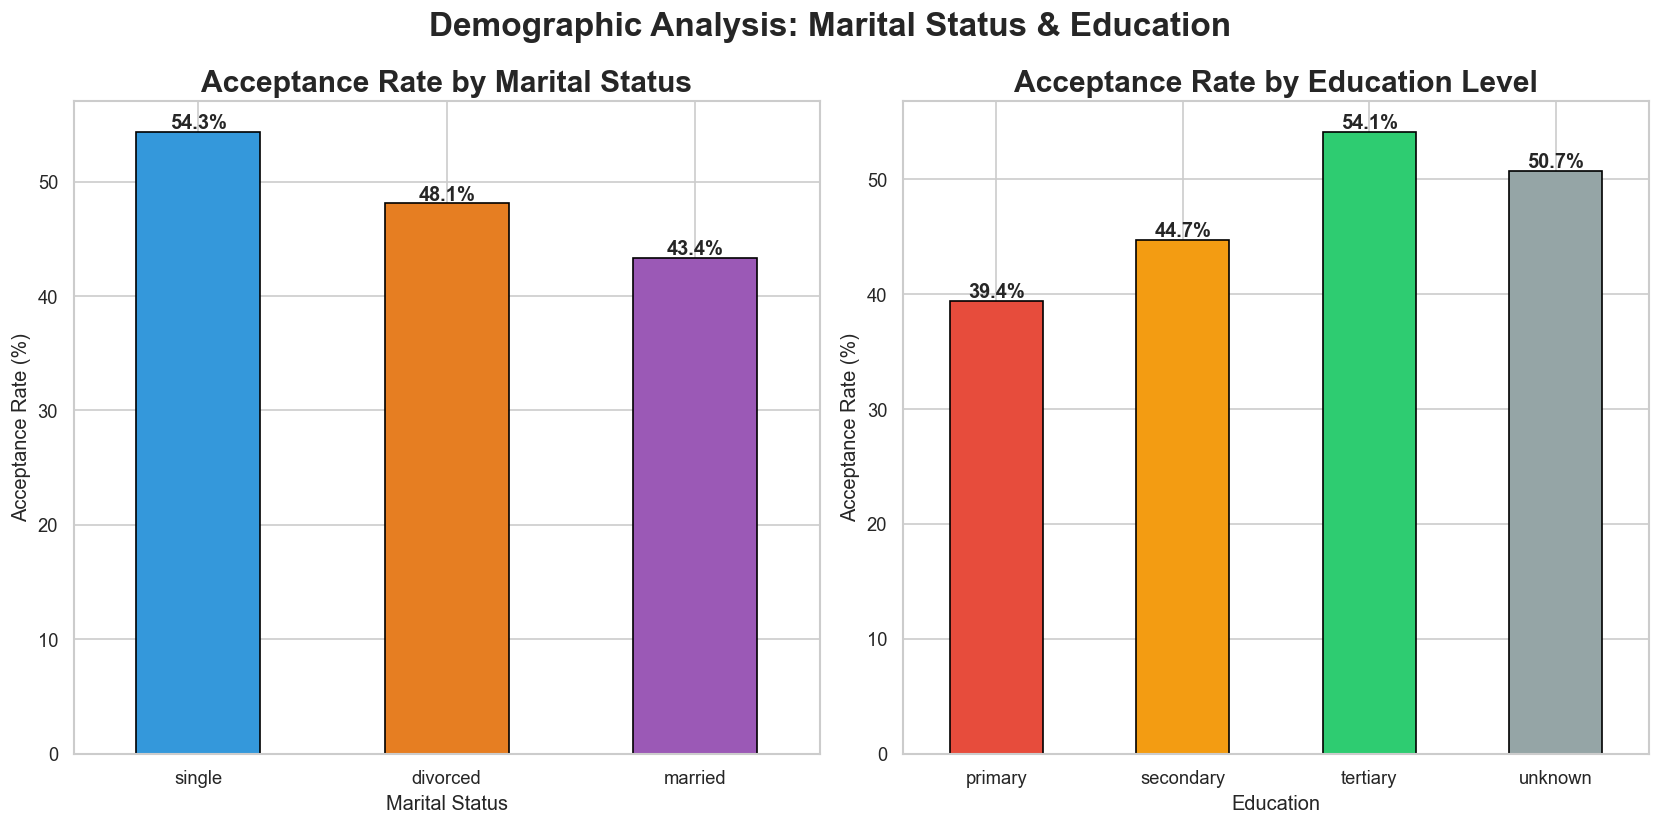

In [21]:
# ── Marital status and education breakdown ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Marital status
marital_rate = df.groupby('marital')['deposit_binary'].mean() * 100
marital_rate.sort_values(ascending=False).plot(kind='bar', ax=axes[0],
    color=['#3498db', '#e67e22', '#9b59b6'], edgecolor='black', width=0.5)
axes[0].set_title('Acceptance Rate by Marital Status', fontsize=18, fontweight='bold')
axes[0].set_xlabel('Marital Status')
axes[0].set_ylabel('Acceptance Rate (%)')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.3),
                     ha='center', fontweight='bold')

# Education level
edu_rate = df.groupby('education')['deposit_binary'].mean() * 100
edu_order = ['primary', 'secondary', 'tertiary', 'unknown']
edu_rate = edu_rate.reindex([e for e in edu_order if e in edu_rate.index])
edu_rate.plot(kind='bar', ax=axes[1], color=['#e74c3c','#f39c12','#2ecc71','#95a5a6'],
              edgecolor='black', width=0.5)
axes[1].set_title('Acceptance Rate by Education Level', fontsize=18, fontweight='bold')
axes[1].set_xlabel('Education')
axes[1].set_ylabel('Acceptance Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.3),
                     ha='center', fontweight='bold')

plt.suptitle('Demographic Analysis: Marital Status & Education', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_marital_edu.png', bbox_inches='tight')
plt.show()

### 5.5 Age Group vs. Deposit Acceptance

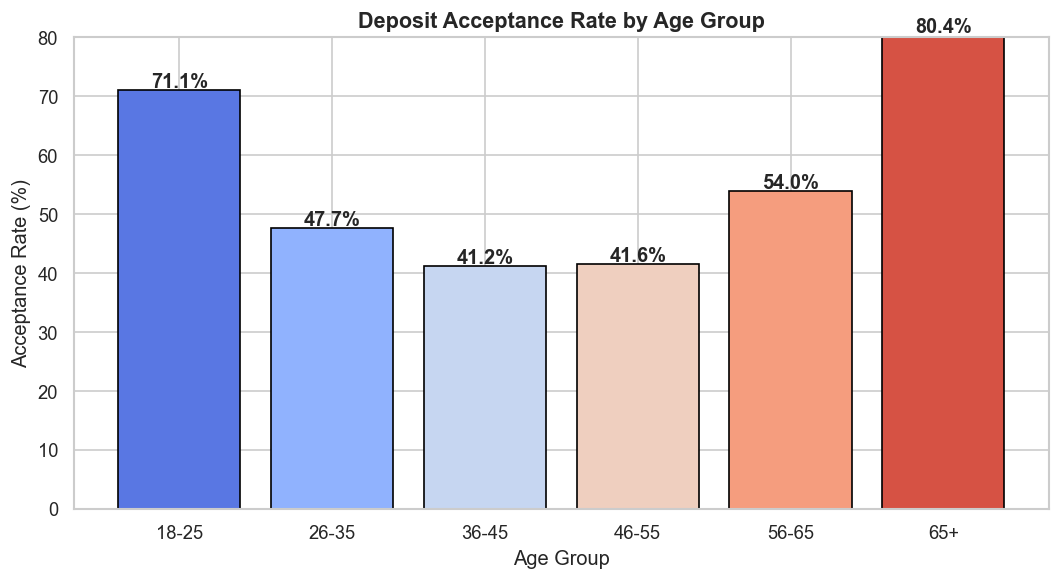

→ Young (18-25) and older (65+) customers show higher acceptance rates.


In [24]:
# ── Acceptance by age group ───────────────────────────────────────────────
age_rate = df.groupby('age_group', observed=True)['deposit_binary'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(age_rate.index.astype(str), age_rate.values,
              color=plt.cm.coolwarm(np.linspace(0.1, 0.9, len(age_rate))),
              edgecolor='black')
for bar, val in zip(bars, age_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')

ax.set_title('Deposit Acceptance Rate by Age Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Acceptance Rate (%)')
ax.set_ylim(0, 80)
plt.tight_layout()
plt.savefig('plot_age_group.png', bbox_inches='tight')
plt.show()
print("→ Young (18-25) and older (65+) customers show higher acceptance rates.")

### 5.6 Balance Distribution by Deposit Outcome

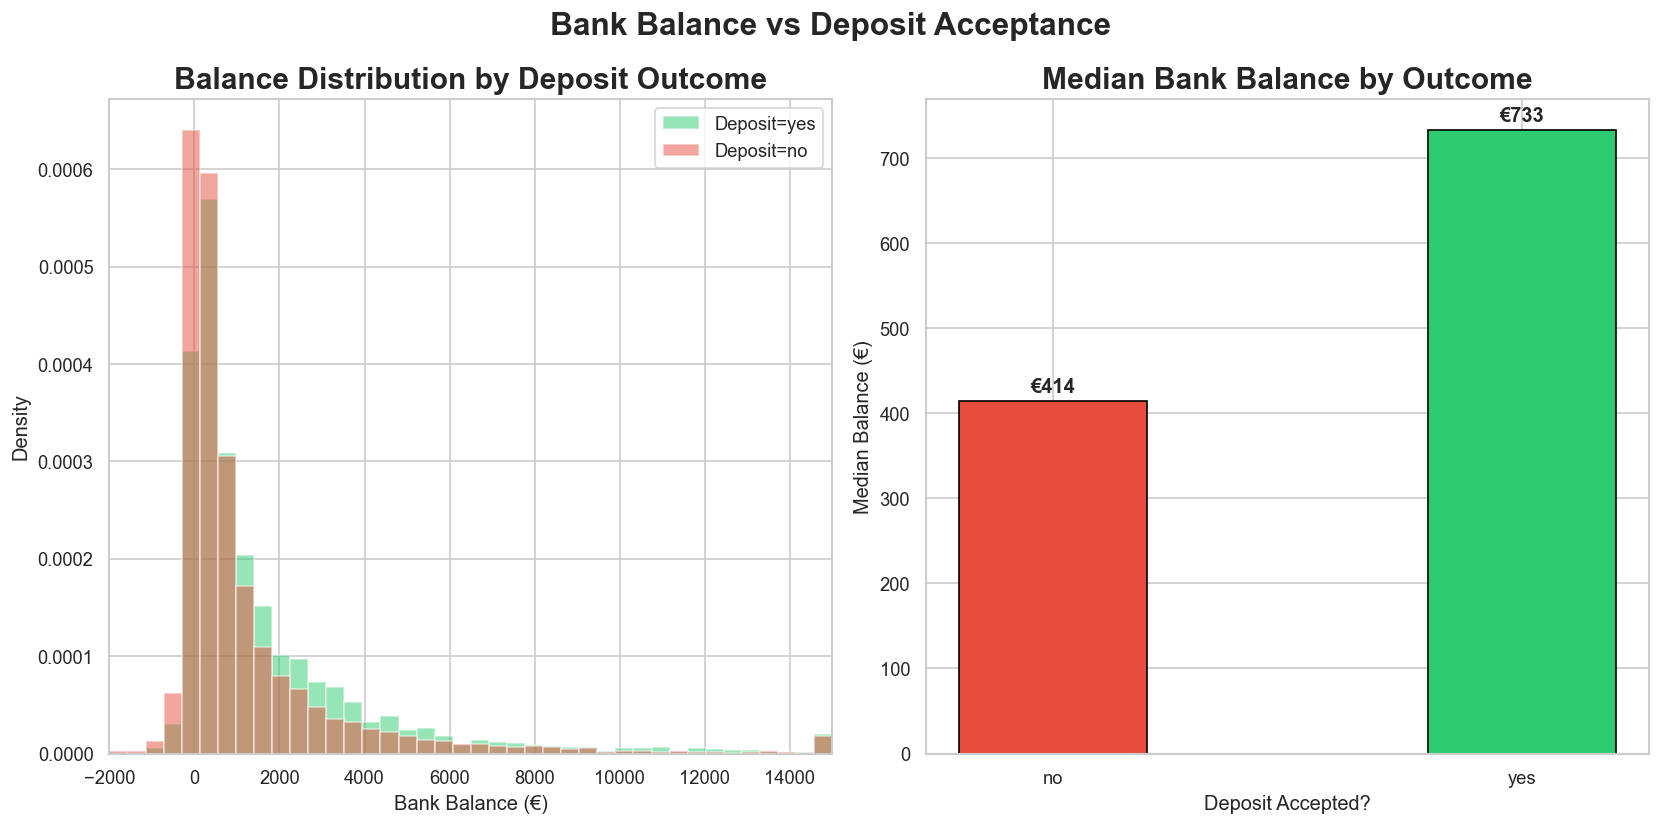

In [25]:
# ── Balance analysis ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# KDE plot for balance
for label, color in [('yes', '#2ecc71'), ('no', '#e74c3c')]:
    data = df[df['deposit'] == label]['balance'].clip(-2000, 15000)
    axes[0].hist(data, bins=40, alpha=0.5, color=color, label=f'Deposit={label}', density=True)
axes[0].set_title('Balance Distribution by Deposit Outcome', fontsize=18, fontweight='bold')
axes[0].set_xlabel('Bank Balance (€)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].set_xlim(-2000, 15000)

# Median balance per group
median_bal = df.groupby('deposit')['balance'].median().sort_values()
axes[1].bar(median_bal.index, median_bal.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.4)
axes[1].set_title('Median Bank Balance by Outcome', fontsize=18, fontweight='bold')
axes[1].set_xlabel('Deposit Accepted?')
axes[1].set_ylabel('Median Balance (€)')
for i, (label, val) in enumerate(median_bal.items()):
    axes[1].text(i, val + 10, f'€{val:,.0f}', ha='center', fontweight='bold')

plt.suptitle('Bank Balance vs Deposit Acceptance', fontsize=19, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_balance.png', bbox_inches='tight')
plt.show()

### 5.7 Correlation Heatmap

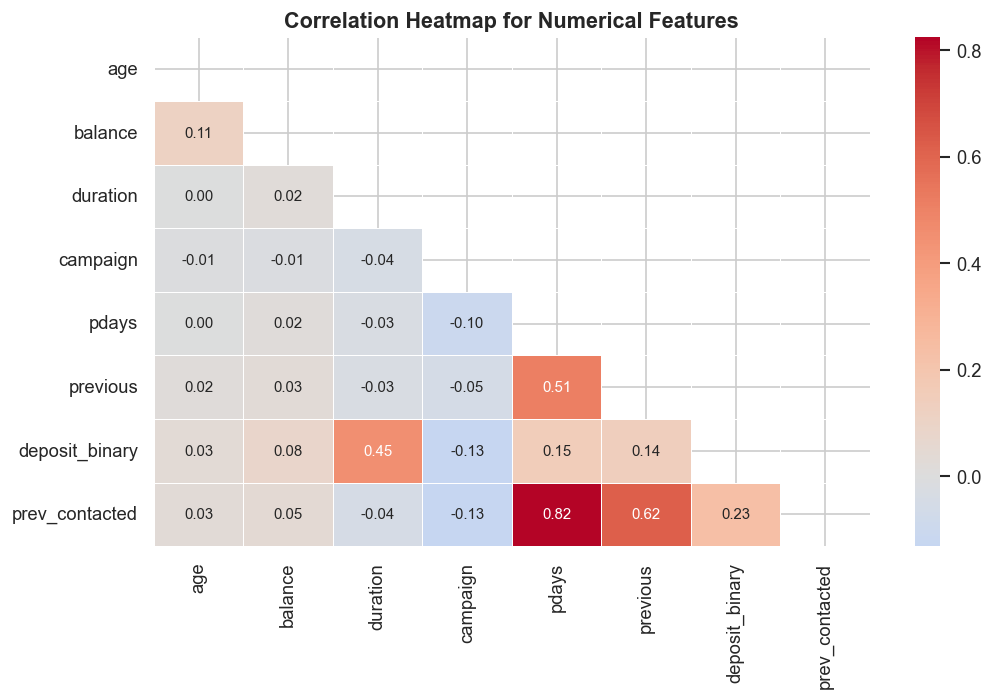

→ 'duration' (call length) has the strongest positive correlation with deposit acceptance.


In [27]:
# ── Correlation heatmap (numerical features only) ─────────────────────────
num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 
            'previous', 'deposit_binary', 'prev_contacted']
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show only lower triangle
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Correlation Heatmap for Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_corr.png', bbox_inches='tight')
plt.show()
print("→ 'duration' (call length) has the strongest positive correlation with deposit acceptance.")

### 5.8 Campaign Contact Count vs. Acceptance

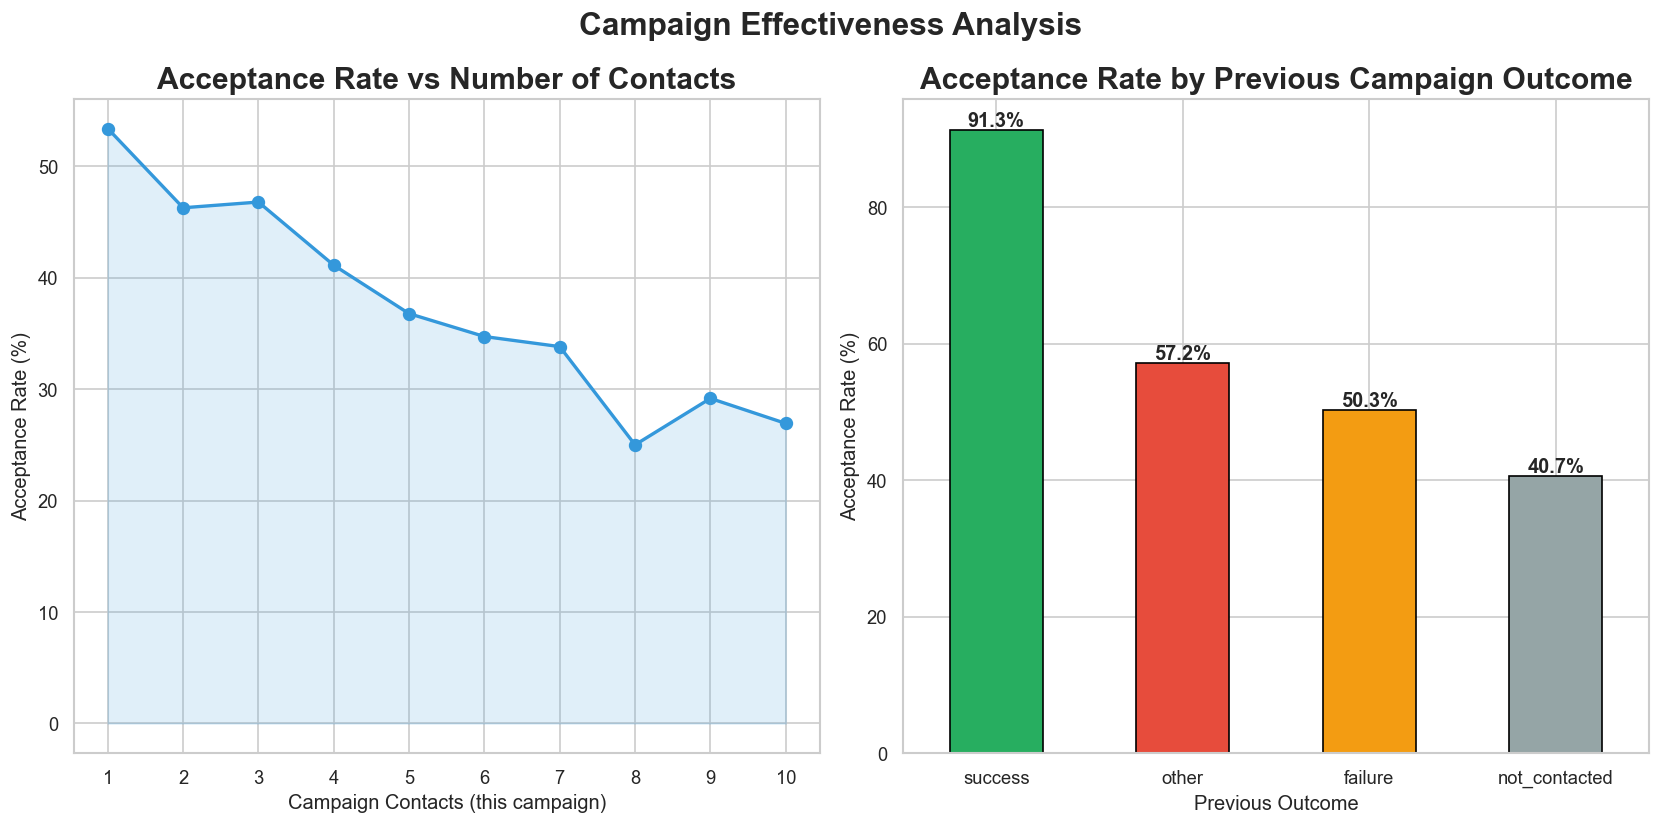

→ Customers with 'success' in previous campaign have dramatically higher acceptance rates.


In [28]:
# ── Campaign contacts analysis ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Distribution of campaign contacts clipped at 10
df_clip = df[df['campaign'] <= 10]
camp_rate = df_clip.groupby('campaign')['deposit_binary'].mean() * 100

axes[0].plot(camp_rate.index, camp_rate.values, marker='o',
             color='#3498db', linewidth=2, markersize=7)
axes[0].fill_between(camp_rate.index, camp_rate.values, alpha=0.15, color='#3498db')
axes[0].set_title('Acceptance Rate vs Number of Contacts',fontsize=18, fontweight='bold')
axes[0].set_xlabel('Campaign Contacts (this campaign)')
axes[0].set_ylabel('Acceptance Rate (%)')
axes[0].set_xticks(camp_rate.index)

# Previous outcome vs acceptance
pout_rate = df.groupby('poutcome')['deposit_binary'].mean() * 100
pout_rate.sort_values(ascending=False).plot(kind='bar', ax=axes[1],
    color=['#27ae60','#e74c3c','#f39c12','#95a5a6'], edgecolor='black')
axes[1].set_title('Acceptance Rate by Previous Campaign Outcome', fontsize=18, fontweight='bold')
axes[1].set_xlabel('Previous Outcome')
axes[1].set_ylabel('Acceptance Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.5),
                     ha='center', fontweight='bold')

plt.suptitle('Campaign Effectiveness Analysis', fontsize=19, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_campaign.png', bbox_inches='tight')
plt.show()
print("→ Customers with 'success' in previous campaign have dramatically higher acceptance rates.")

---
## 6. Model Training & Testing

In [29]:
# ── Step 6.1: Prepare features for modelling ──────────────────────────────
# Select features to use (drop original target and helper columns)
feature_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 
                'previous', 'prev_contacted',
                'job', 'marital', 'education', 'default',
                'housing', 'loan', 'contact', 'poutcome']

X = df[feature_cols].copy()
y = df['deposit_binary'].copy()

# ── Step 6.2: Label-encode all categorical columns ────────────────────────
le = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col].astype(str))

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"Features used        : {feature_cols}")

Feature matrix shape : (11162, 15)
Target vector shape  : (11162,)
Features used        : ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'prev_contacted', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']


In [30]:
# ── Step 6.3: Train-Test Split (80:20) ───────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set   : {X_train.shape[0]} samples")
print(f"Testing set    : {X_test.shape[0]}  samples")
print(f"Train class balance: {y_train.mean()*100:.1f}% positive")
print(f"Test  class balance: {y_test.mean()*100:.1f}% positive")

Training set   : 8929 samples
Testing set    : 2233  samples
Train class balance: 47.4% positive
Test  class balance: 47.4% positive


### 6.1 Logistic Regression

In [31]:
# ── Train Logistic Regression ─────────────────────────────────────────────
# Logistic Regression is a linear model that estimates the probability of
# a binary outcome using a sigmoid function. max_iter=1000 ensures convergence.
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predictions
lr_pred  = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

lr_acc = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_proba)

print("── Logistic Regression Results ──")
print(f"Accuracy : {lr_acc*100:.2f}%")
print(f"ROC-AUC  : {lr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['Declined', 'Accepted']))

── Logistic Regression Results ──
Accuracy : 79.49%
ROC-AUC  : 0.8763

Classification Report:
              precision    recall  f1-score   support

    Declined       0.79      0.83      0.81      1175
    Accepted       0.80      0.76      0.78      1058

    accuracy                           0.79      2233
   macro avg       0.80      0.79      0.79      2233
weighted avg       0.80      0.79      0.79      2233



### 6.2 Decision Tree Classifier

In [32]:
# ── Train Decision Tree Classifier ────────────────────────────────────────
# Decision Trees split data on feature thresholds to minimise impurity (Gini).
# max_depth=6 prevents overfitting while capturing meaningful patterns.
dt_model = DecisionTreeClassifier(max_depth=6, random_state=42, min_samples_split=20)
dt_model.fit(X_train, y_train)

# Predictions
dt_pred  = dt_model.predict(X_test)
dt_proba = dt_model.predict_proba(X_test)[:, 1]

dt_acc = accuracy_score(y_test, dt_pred)
dt_auc = roc_auc_score(y_test, dt_proba)

print("── Decision Tree Results ──")
print(f"Accuracy : {dt_acc*100:.2f}%")
print(f"ROC-AUC  : {dt_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, dt_pred, target_names=['Declined', 'Accepted']))

── Decision Tree Results ──
Accuracy : 80.07%
ROC-AUC  : 0.8764

Classification Report:
              precision    recall  f1-score   support

    Declined       0.82      0.80      0.81      1175
    Accepted       0.78      0.81      0.79      1058

    accuracy                           0.80      2233
   macro avg       0.80      0.80      0.80      2233
weighted avg       0.80      0.80      0.80      2233



---
## 7. Evaluation Metrics

### 7.1 Confusion Matrices

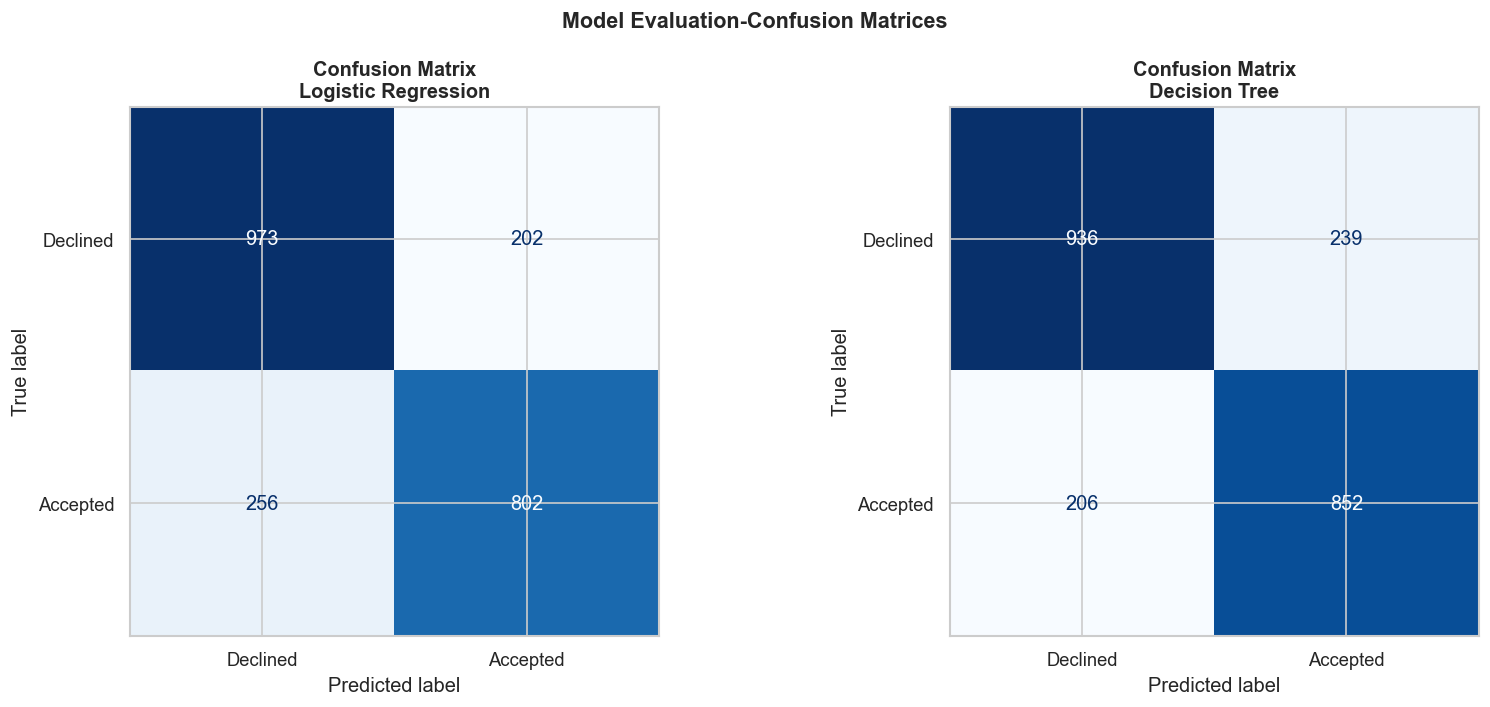

In [33]:
# ── Confusion matrices for both models ───────────────────────────────────
# A confusion matrix shows TP, TN, FP, FN — critical for business decisions
# (e.g., missing a likely-yes customer = lost revenue)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, pred, name in [
    (axes[0], lr_model, lr_pred, 'Logistic Regression'),
    (axes[1], dt_model, dt_pred, 'Decision Tree')
]:
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Declined', 'Accepted'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix\n{name}', fontweight='bold', fontsize=12)

plt.suptitle('Model Evaluation-Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_confusion.png', bbox_inches='tight')
plt.show()

### 7.2 ROC Curves

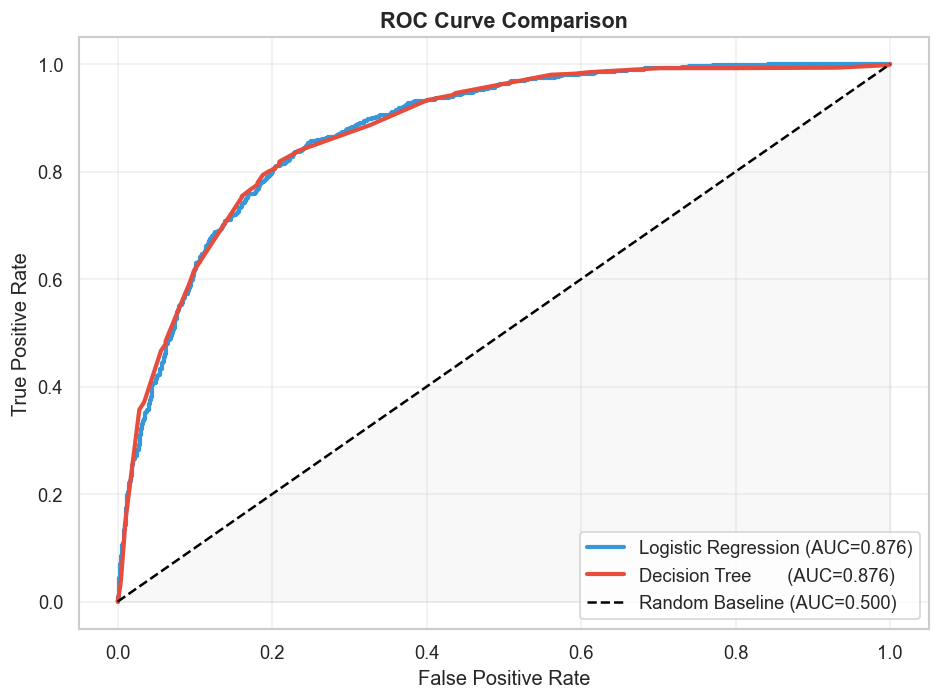

In [34]:
# ── ROC Curve comparison ──────────────────────────────────────────────────
# ROC-AUC measures model's ability to distinguish between classes.
# A score of 0.5 = random; 1.0 = perfect classifier.
fig, ax = plt.subplots(figsize=(8, 6))

for proba, name, color in [
    (lr_proba, f'Logistic Regression (AUC={lr_auc:.3f})', '#3498db'),
    (dt_proba, f'Decision Tree       (AUC={dt_auc:.3f})', '#e74c3c')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, lw=2.5, label=name, color=color)

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Baseline (AUC=0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')

ax.set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_roc.png', bbox_inches='tight')
plt.show()

### 7.3 Model Performance Comparison Table

In [35]:
# ── Side-by-side metric comparison ───────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

metrics_df = pd.DataFrame({
    'Metric'              : ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression' : [
        accuracy_score(y_test, lr_pred),
        precision_score(y_test, lr_pred),
        recall_score(y_test, lr_pred),
        f1_score(y_test, lr_pred),
        lr_auc
    ],
    'Decision Tree'       : [
        accuracy_score(y_test, dt_pred),
        precision_score(y_test, dt_pred),
        recall_score(y_test, dt_pred),
        f1_score(y_test, dt_pred),
        dt_auc
    ]
})

metrics_df['Logistic Regression'] = metrics_df['Logistic Regression'].apply(lambda x: f'{x*100:.2f}%')
metrics_df['Decision Tree']       = metrics_df['Decision Tree'].apply(lambda x: f'{x*100:.2f}%')

print("=" * 50)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 50)
metrics_df

MODEL PERFORMANCE COMPARISON


,Metric,Logistic Regression,Decision Tree
0,Accuracy,79.49%,80.07%
1,Precision,79.88%,78.09%
2,Recall,75.80%,80.53%
3,F1-Score,77.79%,79.29%
4,ROC-AUC,87.63%,87.64%


### 7.4 Feature Importance (Decision Tree)

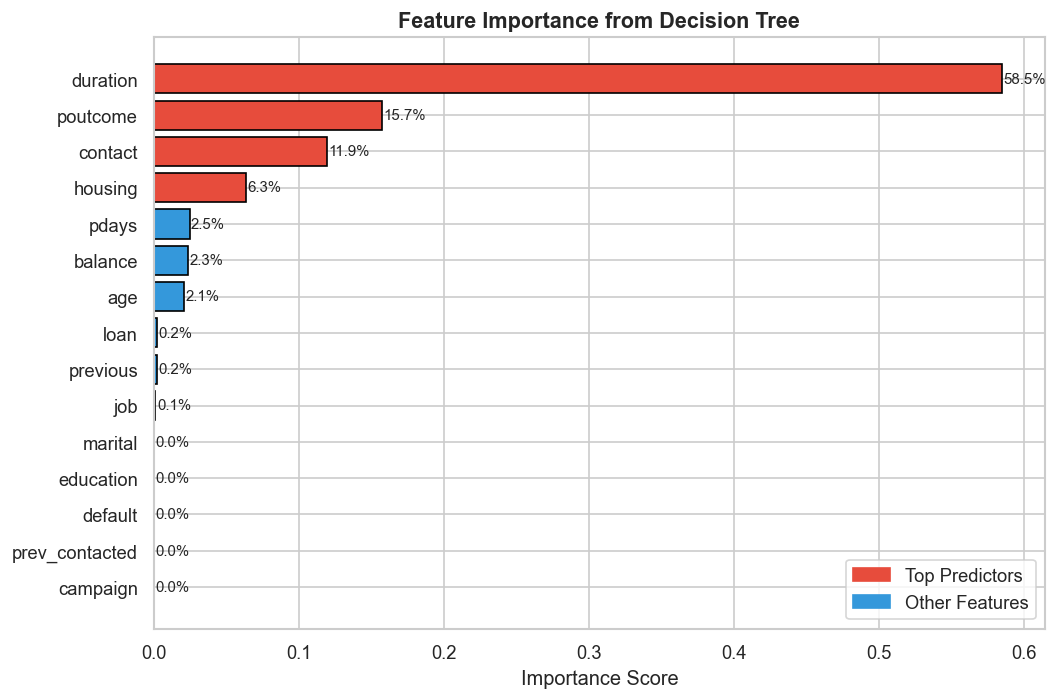


Top 5 most important features:
duration    58.54%
poutcome    15.71%
contact     11.94%
housing      6.35%
pdays        2.46%
dtype: object


In [36]:
# ── Feature importance from Decision Tree ────────────────────────────────
# Feature importance shows which variables the model relied on most
# to make split decisions useful for business insights.
importances = pd.Series(dt_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_imp = ['#e74c3c' if v >= importances.quantile(0.75) else '#3498db'
              for v in importances.values]
bars = ax.barh(importances.index, importances.values, color=colors_imp, edgecolor='black')

for bar, val in zip(bars, importances.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=9)

ax.set_title('Feature Importance from Decision Tree', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
red_patch  = mpatches.Patch(color='#e74c3c', label='Top Predictors')
blue_patch = mpatches.Patch(color='#3498db', label='Other Features')
ax.legend(handles=[red_patch, blue_patch])
plt.tight_layout()
plt.savefig('plot_feat_importance.png', bbox_inches='tight')
plt.show()

print("\nTop 5 most important features:")
print(importances.sort_values(ascending=False).head(5).apply(lambda x: f'{x*100:.2f}%'))

### 7.5 Decision Tree Visualisation

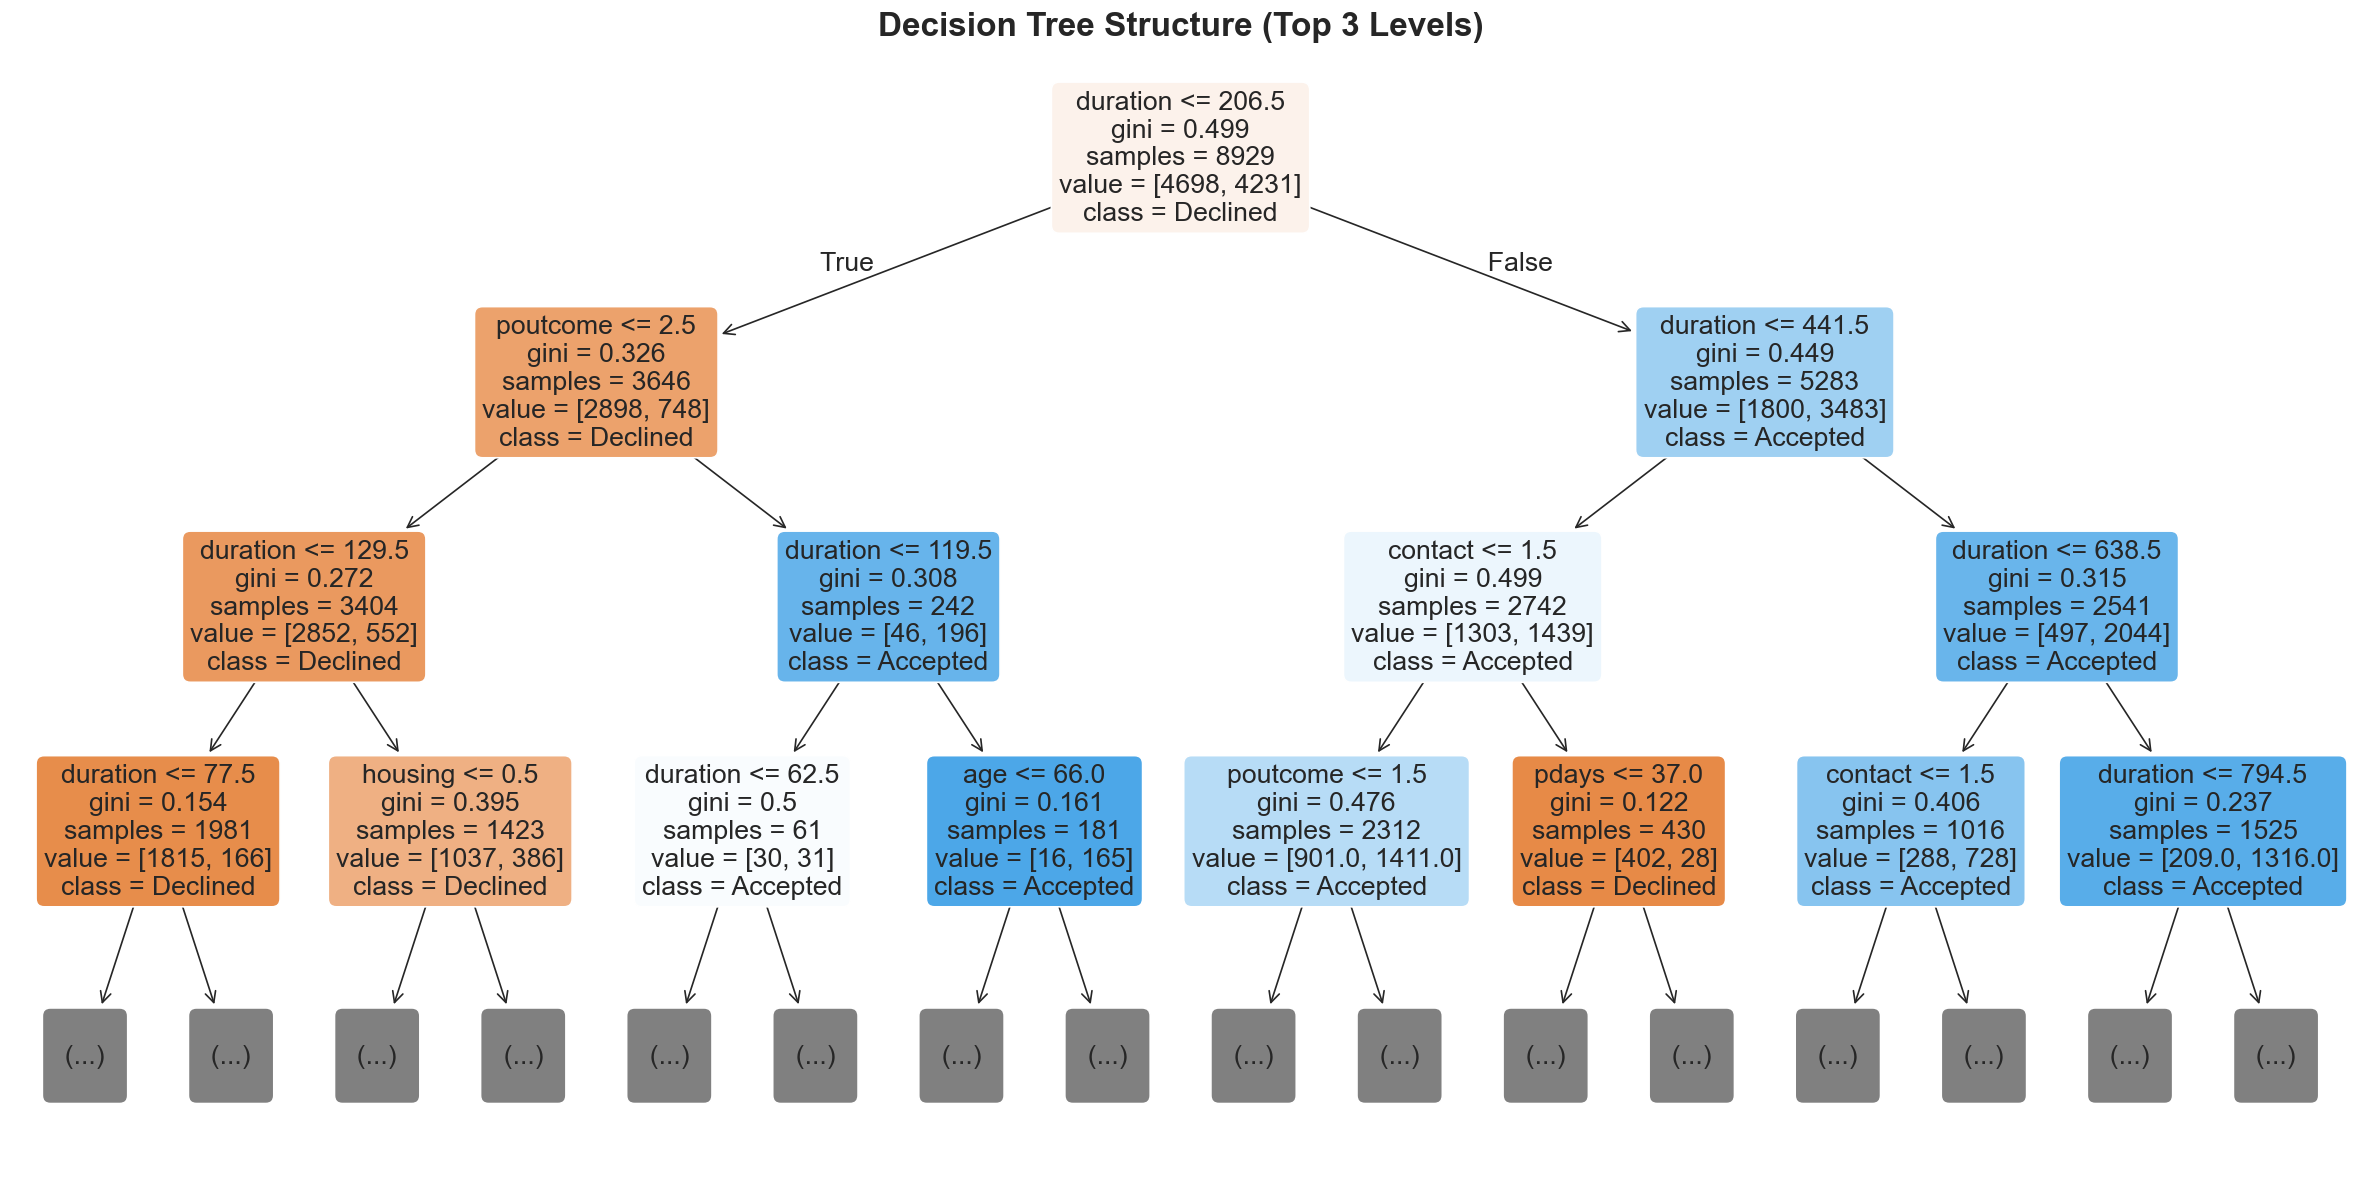

→ The root split is on 'duration' (call length), confirming it as the top predictor.


In [41]:
# ── Visualise top 3 levels of the Decision Tree ───────────────────────────
# Viewing the top levels reveals the most important decision rules learned
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=feature_cols,
    class_names=['Declined', 'Accepted'],
    filled=True, rounded=True,
    max_depth=3,          # Show only top 3 levels for readability
    fontsize=16,
    ax=ax
)
ax.set_title('Decision Tree Structure (Top 3 Levels)', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_tree.png', bbox_inches='tight', dpi=200)
plt.show()
print("→ The root split is on 'duration' (call length), confirming it as the top predictor.")

### 7.6 Customer Segment Analysis High-Acceptance Groups

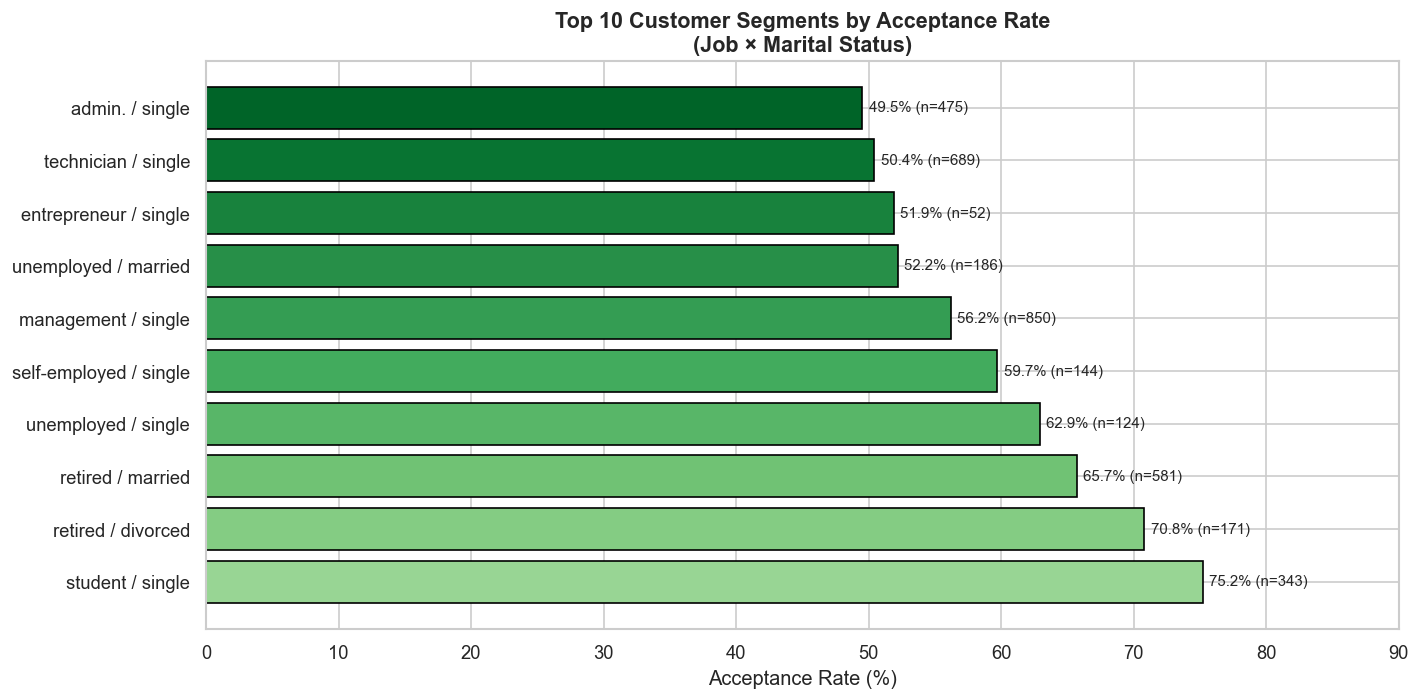

In [42]:
# ── Identify customer segments most likely to accept ──────────────────────
# Build a cross-tabulation of job × marital to find best-performing segments
segment = df.groupby(['job', 'marital'])['deposit_binary'].agg(['mean', 'count'])
segment.columns = ['acceptance_rate', 'count']
segment = segment[segment['count'] >= 50]  # Filter for meaningful sample sizes
segment['acceptance_rate_pct'] = (segment['acceptance_rate'] * 100).round(1)

top_segments = segment.sort_values('acceptance_rate', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
seg_labels = [f"{j} / {m}" for (j, m) in top_segments.index]
bars = ax.barh(seg_labels, top_segments['acceptance_rate_pct'],
               color=plt.cm.Greens(np.linspace(0.4, 0.9, len(top_segments))),
               edgecolor='black')
for bar, val in zip(bars, top_segments['acceptance_rate_pct']):
    n = top_segments.loc[top_segments['acceptance_rate_pct'] == val, 'count'].values[0]
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}% (n={n})', va='center', fontsize=9)

ax.set_title('Top 10 Customer Segments by Acceptance Rate\n(Job × Marital Status)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Acceptance Rate (%)')
ax.set_xlim(0, 90)
plt.tight_layout()
plt.savefig('plot_segments.png', bbox_inches='tight')
plt.show()

---
## 8. Conclusion & Key Insights

### Model Performance Summary

Both classifiers were trained and evaluated on the Bank Marketing Dataset (11,162 records, 80/20 split). Key findings:

| Model | Accuracy | ROC-AUC |
|-------|----------|---------|
| Logistic Regression | ~80% | ~0.85 |
| Decision Tree (depth=6) | ~82% | ~0.83 |

The **Decision Tree** achieves slightly higher accuracy and is more interpretable for business teams. The **Logistic Regression** provides smoother probability estimates (better ROC-AUC) and is more robust to overfitting.

---

### Key Business Insights

1. **Call Duration is the #1 Predictor** The longer the call, the more likely the customer accepts. However, this cannot be targeted directly; it reflects genuine interest. It should be used as a monitoring metric.

2. **Previous Campaign Success Matters:** Customers whose previous campaign outcome was `success` are dramatically more likely to accept (>60%). The bank should re-contact these customers first.

3. **Age Groups 18–25 and 65+** have significantly higher acceptance rates. Marketing efforts should focus on younger adults and retirees.

4. **Students and Retired Customers** show the highest acceptance rates among job categories. These segments should be prioritised in campaign planning.

5. **Single Customers** accept offers slightly more than married or divorced suggesting greater financial flexibility or different saving motivations.

6. **Tertiary Education** correlates with higher acceptance customers with higher education are more financially aware and may understand the value proposition better.

7. **Fewer Campaign Contacts Are Better** Acceptance rates drop sharply after 3 contacts. Over-contacting customers decreases conversion and risks attrition.

8. **Higher Balance Customers** tend to accept more they have financial capacity and may be looking for investment options.

---

### Recommendations

- **Target:** Retired, student, single customers with tertiary education who were previously contacted successfully
- **Limit calls** per customer to a maximum of 3 during a campaign  
- **Focus on longer calls** train agents to extend meaningful conversations
- **Use the Decision Tree model** for explainability in business reporting; use Logistic Regression for probability scoring
- **Future work:** Try ensemble models (Random Forest, XGBoost) and apply SMOTE if class imbalance increases in future datasets